# Color 01 - Palette foundation (Solution)

Muc tieu: map dung loai du lieu vao loai color scale.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "data" / "owid_co2_subset.csv").exists():
            return p
    raise FileNotFoundError("Cannot locate data/owid_co2_subset.csv")

root = resolve_repo_root()
sns.set_theme(style="whitegrid")
df = pd.read_csv(root / "data" / "owid_co2_subset.csv")
# keep country-level rows with key indicators
df = df.dropna(subset=["co2_per_capita", "gdp", "population"]).copy()
d_recent = df[df["year"] >= 2000].copy()
d_latest = d_recent[d_recent["year"] == d_recent["year"].max()].copy()
d_latest.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,energy_per_capita,gas_co2,methane,nitrous_oxide,oil_co2,primary_energy_consumption,temperature_change_from_ghg,trade_co2
32,Afghanistan,2022,AFG,40578847.0,5.330347e+10,10.170,0.251,3.488,1111.573,0.143,16.076,4.419,6.528,45.106,0.001,NaN
67,Albania,2022,ALB,2827614.0,3.617101e+10,4.498,1.591,0.542,9147.205,0.088,2.431,0.864,2.946,25.865,0.000,1.188
102,Algeria,2022,DZA,45477391.0,5.958201e+11,192.779,4.239,0.758,16145.337,101.379,67.576,8.200,61.610,734.248,0.005,NaN
172,Angola,2022,AGO,35635028.0,1.583462e+11,21.089,0.592,NaN,2713.824,1.927,45.564,17.332,14.887,96.707,0.006,NaN
312,Argentina,2022,ARG,45407904.0,8.549144e+11,183.768,4.047,4.731,22049.938,89.620,115.333,50.296,81.967,1001.241,0.016,0.078


## 1) Categorical palette cho bien nominal (`continent`)

Chart phu hop: so sanh giua cac nhom roi rac (khong co thu tu tu nhien).
Mau co vai tro **phan biet nhom** (khong truyen tai magnitude).

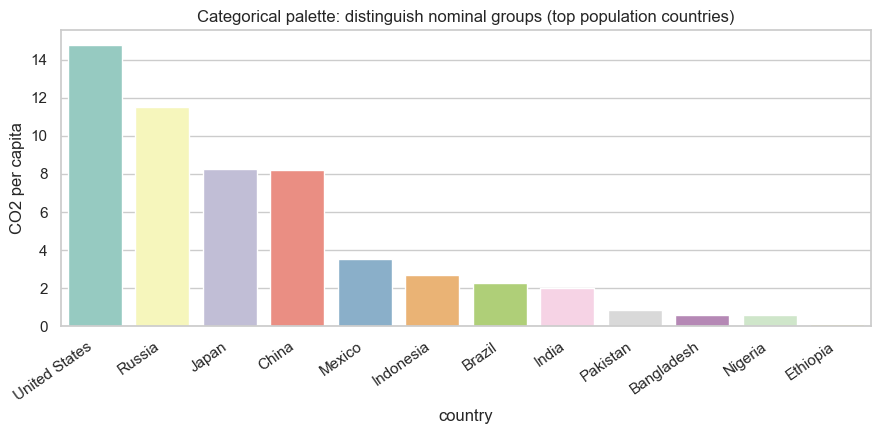

In [2]:
cat_df = (
    d_latest.groupby("country", as_index=False)
    .agg(co2_pc=("co2_per_capita", "mean"), pop=("population", "mean"))
    .nlargest(12, "pop")
    .sort_values("co2_pc", ascending=False)
)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=cat_df,
    x="country",
    y="co2_pc",
    hue="country",
    palette="Set3",
    dodge=False,
    legend=False,
)
plt.title("Categorical palette: distinguish nominal groups (top population countries)")
plt.ylabel("CO2 per capita")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 2) Sequential palette cho bien lien tuc (`gdpPercap`)

Chart phu hop: heatmap/choropleth hoac bang co thu tu.
Mau co vai tro **truyen tai muc do** (light -> dark).

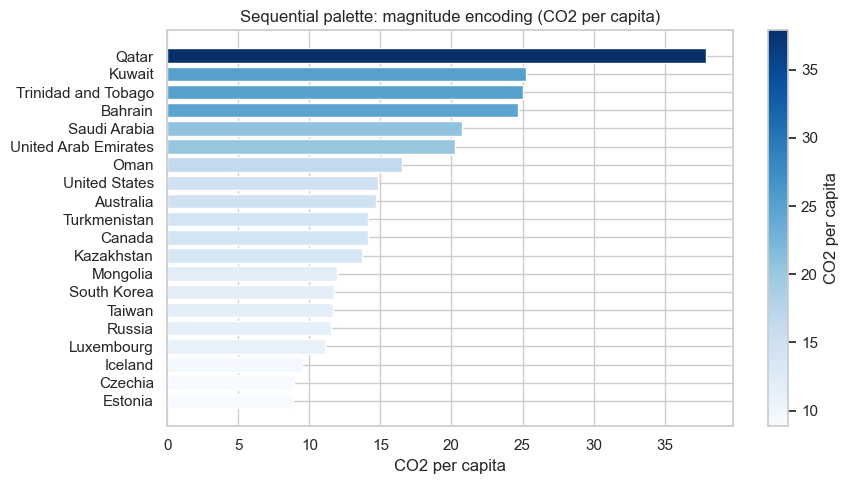

In [3]:
seq_df = (
    d_latest.groupby("country", as_index=False)
    .agg(co2_pc=("co2_per_capita", "mean"))
    .nlargest(20, "co2_pc")
    .sort_values("co2_pc", ascending=False)
)

norm = plt.Normalize(seq_df["co2_pc"].min(), seq_df["co2_pc"].max())
cmap = plt.cm.Blues
colors = cmap(norm(seq_df["co2_pc"].to_numpy()))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(seq_df["country"], seq_df["co2_pc"], color=colors)
ax.set_title("Sequential palette: magnitude encoding (CO2 per capita)")
ax.set_xlabel("CO2 per capita")
ax.invert_yaxis()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="CO2 per capita")
plt.tight_layout(); plt.show()

## 3) Diverging palette khi co diem giua co y nghia (0)

Ta tao bien `lifeExp_delta` = lifeExp(country) - median(2007).
Chart phu hop: bar theo do lech dau (+/-) quanh moc trung tam.

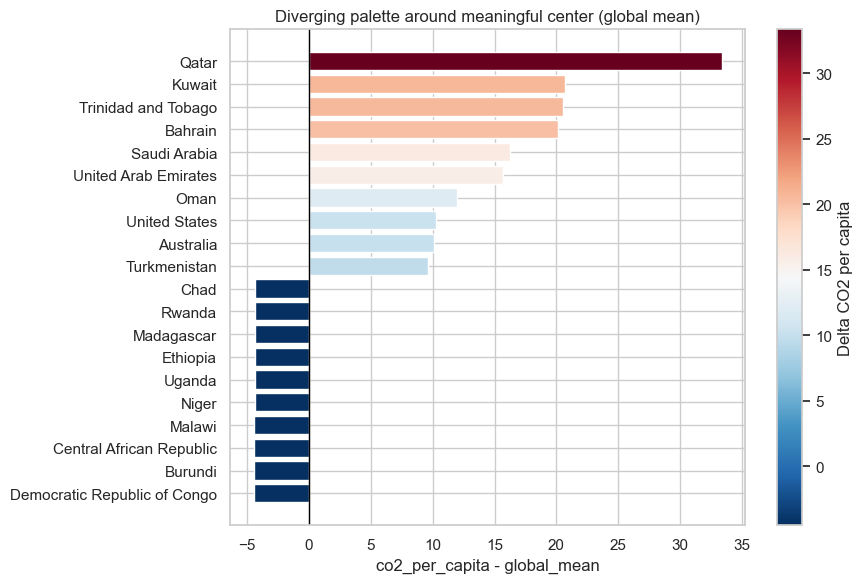

In [4]:
global_mean = d_latest["co2_per_capita"].mean()
d_latest["co2_pc_delta"] = d_latest["co2_per_capita"] - global_mean
focus = pd.concat(
    [d_latest.nsmallest(10, "co2_pc_delta"), d_latest.nlargest(10, "co2_pc_delta")],
    ignore_index=True,
).sort_values("co2_pc_delta")

v = focus["co2_pc_delta"].to_numpy()
norm = plt.Normalize(v.min(), v.max())
cmap = plt.cm.RdBu_r
colors = cmap(norm(v))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(focus["country"], focus["co2_pc_delta"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Diverging palette around meaningful center (global mean)")
ax.set_xlabel("co2_per_capita - global_mean")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Delta CO2 per capita")
plt.tight_layout(); plt.show()

## Reflection
- Vi sao khong dung palette categorical cho bien lien tuc?
- Neu khong co moc 0/target ro rang, ban co dung diverging khong?